In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

# (한글 폰트 설정 - 선택)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 파일 읽기 및 컬럼 분리
df = pd.read_csv('./data/PJM_Load_hourly.txt', header=None, names=['datetime_raw', 'load'])
# 시간 문자열 합치기(날짜와 시간 뒷자리)
df = df.iloc[1:].reset_index(drop=True)

df['datetime'] = df['datetime_raw'].str.replace(' ', '') # 혹은 적절한 split/정규식 조정

df['datetime'] = pd.to_datetime(df['datetime_raw'], format='%Y-%m-%d %H:%M')
df = df.set_index('datetime')
df = df[['load']]


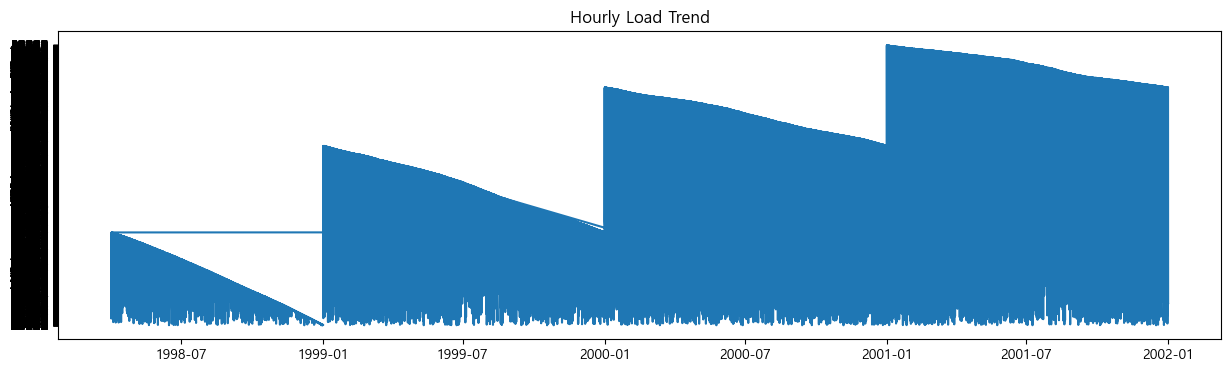

         load
count   32896
unique  16865
top     30723
freq       10
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32896 entries, 1998-12-31 01:00:00 to 2001-01-02 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   load    32896 non-null  object
dtypes: object(1)
memory usage: 514.0+ KB
None


In [12]:

# 전체 추세 시각화
plt.figure(figsize=(15,4))
plt.plot(df['load'])
plt.title('Hourly Load Trend')
plt.show()

# 요약 통계
print(df.describe())
print(df.info())


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


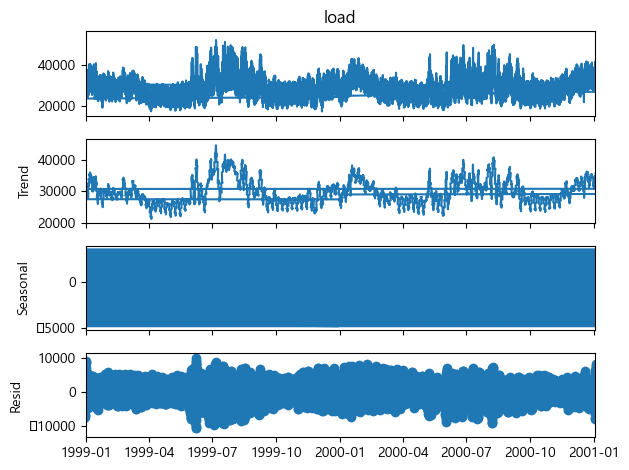

In [13]:
import statsmodels.api as sm

# 분해 시각화 (추세, 계절성, 잔차)
decomposition = sm.tsa.seasonal_decompose(df['load'], model='additive', period=24)
decomposition.plot()
plt.show()


In [14]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['load'], order=(2,0,2))
model_fit = model.fit()
print(model_fit.summary())

# 예측 및 비교
df['arima_pred'] = model_fit.predict(start=0, end=len(df)-1)
plt.plot(df['load'], label='Actual')
plt.plot(df['arima_pred'], label='ARIMA Forecast')
plt.legend()
plt.show()


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
from prophet import Prophet

df_prophet = df.reset_index().rename(columns={"datetime":"ds","load":"y"})
m = Prophet(daily_seasonality=True)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=24*7, freq='H')
forecast = m.predict(future)

plt.figure(figsize=(15,4))
plt.plot(df['load'].values, label='Actual')
plt.plot(forecast['yhat'], label='Prophet Forecast')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

arima_rmse = mean_squared_error(df['load'][24:], df['arima_pred'][24:], squared=False)
arima_mape = mean_absolute_percentage_error(df['load'][24:], df['arima_pred'][24:])

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAPE: {arima_mape:.2%}")

# Prophet 평가도 유사 방식으로 future 기간에서 실제값 비교
